In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

Image shape: (512, 512)


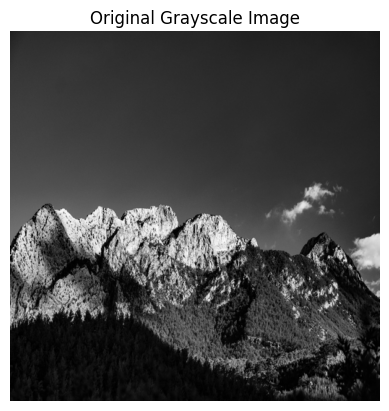

In [2]:
def preprocess_image(image_path, target_size=(512, 512), block_size=8):
    img = Image.open(image_path).convert("L")  # grayscale
    img = img.resize(target_size, Image.BICUBIC)  # recommended size
    arr = np.array(img, dtype=np.float64)
    
    H, W = arr.shape
    H2, W2 = (H // block_size) * block_size, (W // block_size) * block_size
    return arr[:H2, :W2]

IMAGE_PATH = "mountains.jpeg"  

I = preprocess_image(IMAGE_PATH, target_size=(512, 512), block_size=8)
print("Image shape:", I.shape)

plt.figure()
plt.imshow(I, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()

In [3]:
def compress_block(block, k):
    U, S, Vt = np.linalg.svd(block, full_matrices=False)
    Uk = U[:, :k]
    Sk = S[:k]
    Vtk = Vt[:k, :]
    return Uk @ np.diag(Sk) @ Vtk

In [4]:
def blockwise_svd_compress(image, k, block_size=8):
    H, W = image.shape
    out = np.zeros_like(image)

    for r in range(0, H, block_size):
        for c in range(0, W, block_size):
            block = image[r:r+block_size, c:c+block_size]
            out[r:r+block_size, c:c+block_size] = compress_block(block, k)

    out = np.clip(out, 0, 255)
    return out

In [5]:
def compression_ratio(block_size, k):
    # original = b^2, retained = k*(2b+1)
    b = block_size
    return (b*b) / (k*(2*b + 1))

def frobenius_error(original, recon):
    return np.linalg.norm(original - recon, 'fro')

def psnr(original, recon, max_val=255.0):
    mse = np.mean((original - recon)**2)
    if mse == 0:
        return float("inf")
    return 20*np.log10(max_val) - 10*np.log10(mse)

In [6]:
ks = list(range(1, 9))
CRs, Errors, PSNRs = [], [], []
recons = {}

for k in ks:
    recon = blockwise_svd_compress(I, k, block_size=8)
    recons[k] = recon

    CRs.append(compression_ratio(8, k))
    Errors.append(frobenius_error(I, recon))
    PSNRs.append(psnr(I, recon))

    # Save recon image
    Image.fromarray(recon.astype(np.uint8)).save(os.path.join(OUTPUT_DIR, f"recon_k{k}.png"))

print("Saved reconstructed images in:", OUTPUT_DIR)

print(f"{'k':>2} | {'Compression Ratio':>17} | {'Frob Error':>12} | {'PSNR (dB)':>9}")
print("-"*55)
for k, cr, err, p in zip(ks, CRs, Errors, PSNRs):
    print(f"{k:>2} | {cr:>17.4f} | {err:>12.2f} | {p:>9.2f}")

Saved reconstructed images in: outputs
 k | Compression Ratio |   Frob Error | PSNR (dB)
-------------------------------------------------------
 1 |            3.7647 |      7093.79 |     25.30
 2 |            1.8824 |      4287.20 |     29.67
 3 |            1.2549 |      2666.61 |     33.80
 4 |            0.9412 |      1628.16 |     38.08
 5 |            0.7529 |       924.83 |     43.00
 6 |            0.6275 |       453.66 |     49.18
 7 |            0.5378 |       154.19 |     58.56
 8 |            0.4706 |         0.00 |    300.83


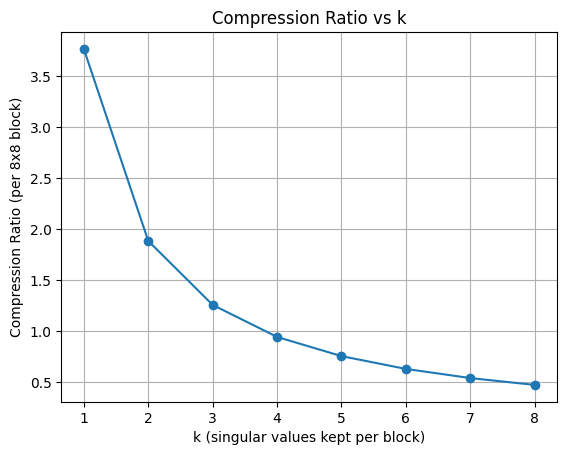

In [7]:
plt.figure()
plt.plot(ks, CRs, marker="o")
plt.xticks(ks)
plt.xlabel("k (singular values kept per block)")
plt.ylabel("Compression Ratio (per 8x8 block)")
plt.title("Compression Ratio vs k")
plt.grid(True)
plt.savefig(os.path.join(OUTPUT_DIR, "compression_ratio_vs_k.png"), dpi=200, bbox_inches="tight")
plt.show()

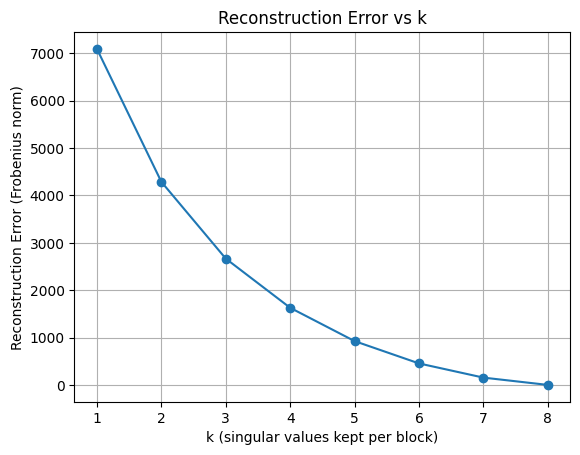

In [10]:
plt.figure()
plt.plot(ks, Errors, marker="o")
plt.xticks(ks)
plt.xlabel("k (singular values kept per block)")
plt.ylabel("Reconstruction Error (Frobenius norm)")
plt.title("Reconstruction Error vs k")
plt.grid(True)
plt.savefig(os.path.join(OUTPUT_DIR, "frob_error_vs_k.png"), dpi=200, bbox_inches="tight")
plt.show()

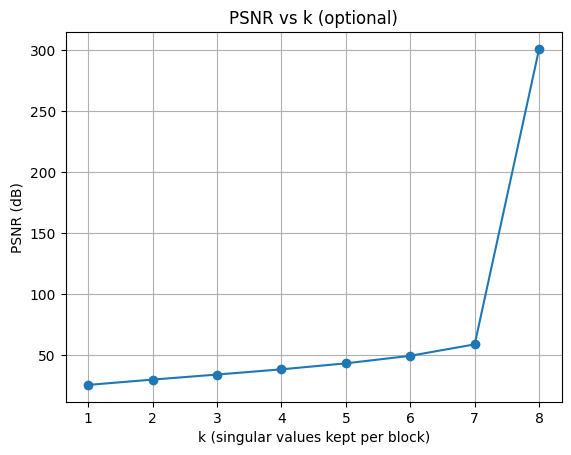

In [8]:
plt.figure()
plt.plot(ks, PSNRs, marker="o")
plt.xticks(ks)
plt.xlabel("k (singular values kept per block)")
plt.ylabel("PSNR (dB)")
plt.title("PSNR vs k (optional)")
plt.grid(True)
plt.savefig(os.path.join(OUTPUT_DIR, "psnr_vs_k.png"), dpi=200, bbox_inches="tight")
plt.show()

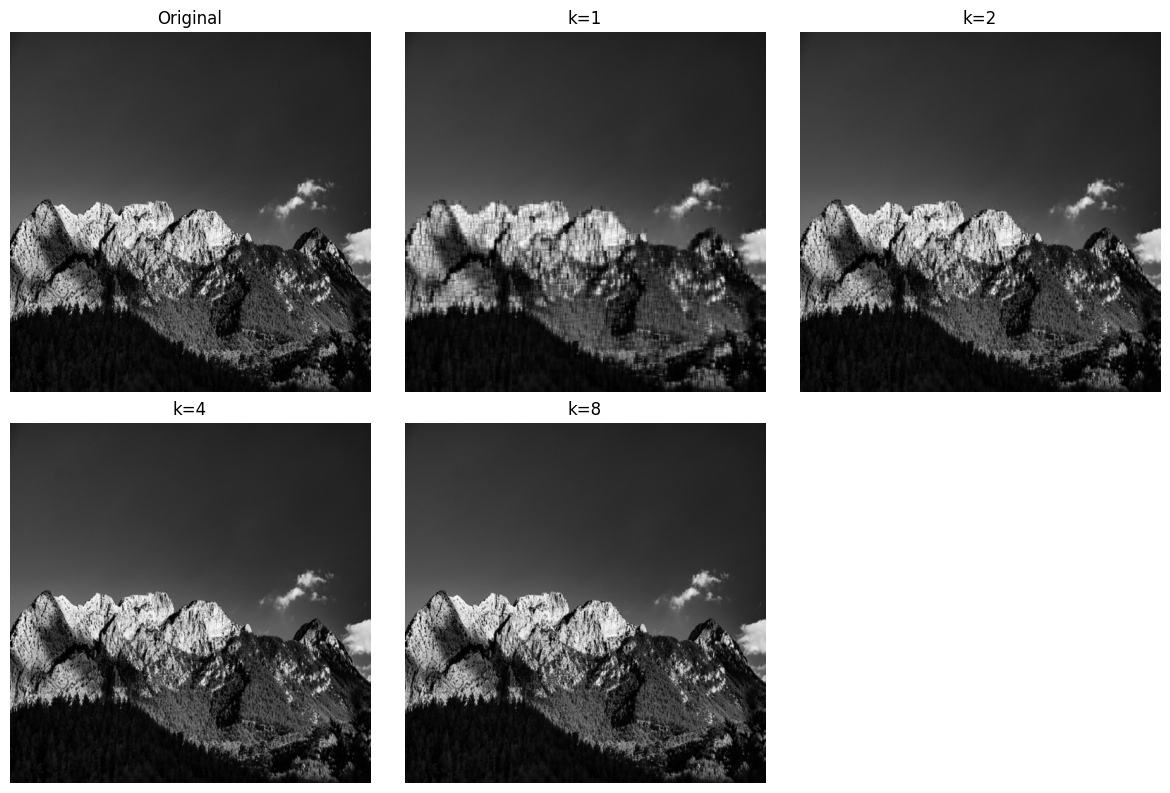

In [9]:
show_ks = [1, 2, 4, 8]
plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(I, cmap="gray")
plt.title("Original")
plt.axis("off")

for i, k in enumerate(show_ks, start=2):
    plt.subplot(2, 3, i)
    plt.imshow(recons[k], cmap="gray")
    plt.title(f"k={k}")
    plt.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "visual_comparison.png"), dpi=200, bbox_inches="tight")
plt.show()